In [1]:
import maboss
import scanpy as sc
import liana as li
from pathlib import Path
import os

cwd=Path.cwd()
if cwd.name == "notebooks":
    os.chdir(cwd.parent) 
os.getcwd()

'/home/maxi7524/repositories/project_computational_biology_initial_conditions_pymyboss'

## Loading part


## Remarks 

### loading resources

Here i load RNA data, important is that we need to:
- use proper resource for LIG/REC pairs tokens 
- select proper in aggregate functions (many samples does met criterias )

In [2]:
# Define path to the data prepared by the bash script
cell_fate_dir = "data/maboss/CellFate"

# Check if the directory structure exists
if os.path.exists(os.path.join(cell_fate_dir, "filtered_feature_bc_matrix.h5")):
    print("Starting the loading of Visium spatial data...")

    # sc.read_visium looks by default for a file named 'filtered_feature_bc_matrix.h5'
    # and a 'spatial/' subdirectory inside the provided path
    adata = sc.read_visium(path=cell_fate_dir, count_file="filtered_feature_bc_matrix.h5")

    # Initial cleanup of index names (optional, but recommended for OmniPath/LIANA+ integration)
    adata.var_names_make_unique()

    print("\n[OK] AnnData object has been created successfully!")
    print(adata)
else:
    print(
        f"[ERROR] Files not found in: '{cell_fate_dir}'."
        "\nMake sure the data download script (bash) was executed correctly."
    )

Starting the loading of Visium spatial data...


/tmp/ipykernel_37438/839064779.py:10: FutureWarning: Use `squidpy.read.visium` instead.



[OK] AnnData object has been created successfully!
AnnData object with n_obs × n_vars = 3798 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.


/tmp/ipykernel_651745/1957829588.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
... storing 'feature_types' as categorical
... storing 'genome' as categorical


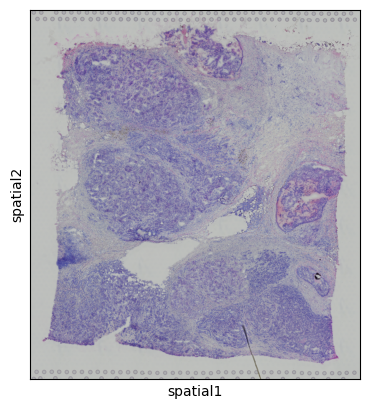

In [3]:
# spatial data display 
sc.pl.spatial(adata=adata)

## Preprocessing

In [6]:
## Preserving raw matrix
adata.raw = adata

In [7]:
## Library size normalization 
sc.pp.normalize_total(adata, target_sum=1e4)

## Log-transformation
sc.pp.log1p(adata)


## Liana setup

In [11]:
# information about given data
adata

AnnData object with n_obs × n_vars = 3798 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'log1p'
    obsm: 'spatial'

In [8]:
## calculate bandwidth value
plot, df_bandwith_vs_neighbours = li.ut.query_bandwidth(coordinates=adata.obsm['spatial'], start=0, end=500, interval_n=20)
df_bandwith_vs_neighbours

,bandwith,neighbours
0,0.000000,0.0
1,26.315789,0.0
2,52.631579,0.0
3,78.947368,0.0
4,105.263158,0.0
5,131.578947,0.0
6,157.894737,0.0
7,184.210526,0.0
8,210.526316,0.0
9,236.842105,0.0


In [9]:
## calculate minimum bandwidth for which we obtain all neighbors
min_bandwidth = df_bandwith_vs_neighbours[df_bandwith_vs_neighbours['neighbours'] >= 6]['bandwith'].min()
min_bandwidth


np.float64(289.4736842105263)

In [ ]:
## Obtain neighbors data
li.utils.spatial_neighbors(
    adata, 
    bandwidth=min_bandwidth, 
    cutoff=0.1, 
    kernel='gaussian', 
    set_diag=False,
    
)

In [11]:
li.mt.bivariate(
    adata,
    local_name='cosine',
    global_name=None,
    # REMARK - this depends on speciee
    resource_name='consensus',
     # graph key for `SpatialEnvironment`
    connectivity_key='spatial_connectivities',
    n_perms=None,
    mask_negatives=True, # we remove noise 
    use_raw=False,
    seed=1337
)

/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.


AnnData object with n_obs × n_vars = 3798 × 1628
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'ligand', 'receptor', 'ligand_means', 'ligand_props', 'receptor_means', 'receptor_props', 'mean', 'std'
    uns: 'spatial', 'log1p'
    obsm: 'spatial'
    obsp: 'spatial_connectivities'

## Model configuration 

In [3]:
from MaBossSpatial import SpatialBooleanPipeline 

In [4]:
adata

AnnData object with n_obs × n_vars = 3798 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [5]:
# Setting up pipeline 

## initialization
pipeline = SpatialBooleanPipeline(
    ## adata file, REMARK: it need to contain liana results
    spatial_data=adata, 
    ## value with liana results, you can find it in adata.uns.keys()
    liana_uns_key='liana_res' 
) 

## loading PyMyBoss model
pipeline.SetMaBossModel(
    mode='pretrained',
    model_name='Creative_name',
    bnd_path='data/maboss/CellFate/model/CellFateModel.bnd',
    cfg_path='data/maboss/CellFate/model/CellFateModel.cfg'
)
## Set spatial environment settings
pipeline.BuildSpatialContext()
## Set time lags
pipeline.SetTimeLags(strategy="experimental", custom_lags={"TNF": 10.0, "FAS": 15.0})
## set simulations settings
pipeline.SetSimulationSettings(max_time=45.0, delta_t=5.0, sample_count=1000)

pipeline.CheckConfiguration()

Successfully loaded pretrained MaBoSS model 'Creative_name' with 28 nodes.
                 LIANA+ SPATIAL CONTEXT ESTIMATION & AUDIT
[!] Critical: Raw integer counts detected in adata.X! Triggering automated log-normalization...
    - Freezing raw integer counts inside backup register: adata.raw
    - Executing total library size normalization (target_sum=1e4)...
    - Appending natural log transformation: log1p...
[✓] Preprocessing sequence completed successfully.

[-] Evaluating optimal spatial propagation constraints via query_bandwidth...
    - Resolved minimum mathematical bandwidth for unified connectivity (k>=6): 289.4736842105263
[-] Initial Empirical Estimates:
    Spatial Neighbors : {'adata': AnnData object with n_obs × n_vars = 3798 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'log1p'
    obsm: 'spatial', 'kernel': 'gaussian', 'bandwidth': 289.4736842105263, 'cutoff': 0.1, 'set_diag': False, 'key_

/home/maxi7524/micromamba/envs/sc_env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.


[✓] Bivariate results successfully mapped into adata.uns['liana_res']
                    SPATIAL BOOLEAN PIPELINE CONFIGURATION REPORT

[ COMPATIBILITY ALERT ]
--------------------------------------------------------------------------------
✅  Success: Intracellular model and Spatial dataset nomenclatures appear aligned.

--- 1. MODEL TOPOLOGY & MAPPING STATUS ---
    Total Managed Network Nodes: 28
    Directly Mapped Gene Overlaps (Total): 7
	- BAX        -> Mapped to adata.var_names['BAX']
	- BCL2       -> Mapped to adata.var_names['BCL2']
	- CASP3      -> Mapped to adata.var_names['CASP3']
	- CASP8      -> Mapped to adata.var_names['CASP8']
	- FADD       -> Mapped to adata.var_names['FADD']
	... and 2 more genes.

--- 1b. CRITICAL INPUT NODES VALIDATION ---
    Total Required Input Nodes : 28
    Overlapping Input Nodes     : 7 / 28
    ⚠️  WARNING: Missing Critical Input Nodes! The model will not function correctly without them.
    -> Missing Inputs (21): ATP, Apoptosis, Cyt_c, 

In [6]:
pipeline.CheckConfiguration(True)

                    SPATIAL BOOLEAN PIPELINE CONFIGURATION REPORT

[ COMPATIBILITY ALERT ]
--------------------------------------------------------------------------------
✅  Success: Intracellular model and Spatial dataset nomenclatures appear aligned.

--- 1. MODEL TOPOLOGY & MAPPING STATUS ---
    Total Managed Network Nodes: 28
    Directly Mapped Gene Overlaps (Total): 7
	- BAX        -> Mapped to adata.var_names['BAX']
	- BCL2       -> Mapped to adata.var_names['BCL2']
	- CASP3      -> Mapped to adata.var_names['CASP3']
	- CASP8      -> Mapped to adata.var_names['CASP8']
	- FADD       -> Mapped to adata.var_names['FADD']
	- TNF        -> Mapped to adata.var_names['TNF']
	- XIAP       -> Mapped to adata.var_names['XIAP']

--- 1b. CRITICAL INPUT NODES VALIDATION ---
    Total Required Input Nodes : 28
    Overlapping Input Nodes     : 7 / 28
    ⚠️  WARNING: Missing Critical Input Nodes! The model will not function correctly without them.
    -> Missing Inputs (21): ATP, Apoptosis,

In [7]:
target_cells = adata.obs_names[:2].tolist()
output_path = "data/maboss/real_simulation_results.csv"

pipeline.RunPipeline(target_cell_ids=target_cells, output_csv_path=output_path)

Extracting active simulation and context boundary subgraphs...
Evaluating biological time lags for active pathways...
                    SPATIAL BOOLEAN PIPELINE CONFIGURATION REPORT

[ COMPATIBILITY ALERT ]
--------------------------------------------------------------------------------
✅  Success: Intracellular model and Spatial dataset nomenclatures appear aligned.

--- 1. MODEL TOPOLOGY & MAPPING STATUS ---
    Total Managed Network Nodes: 28
    Directly Mapped Gene Overlaps (Total): 7
	- BAX        -> Mapped to adata.var_names['BAX']
	- BCL2       -> Mapped to adata.var_names['BCL2']
	- CASP3      -> Mapped to adata.var_names['CASP3']
	- CASP8      -> Mapped to adata.var_names['CASP8']
	- FADD       -> Mapped to adata.var_names['FADD']
	... and 2 more genes.

--- 1b. CRITICAL INPUT NODES VALIDATION ---
    Total Required Input Nodes : 28
    Overlapping Input Nodes     : 7 / 28
    ⚠️  WARNING: Missing Critical Input Nodes! The model will not function correctly without them.
   